# Analysing Brownian dynamics simulations of condensate formation with option for surface condensation

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import readdy
import math
import scipy
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap
import time
import scipy.integrate as integrate
print(readdy.__version__)
from scipy.spatial.transform import Rotation as Rot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import skimage
from skimage import measure   
import matplotlib.gridspec as gridspec
from sklearn.cluster import DBSCAN
from sklearn import metrics
from collections import Counter
from jakteristics import compute_features
import matplotlib.patches as patches
from pylab import setp
import copy
from joblib import Parallel, delayed
from scipy.stats import sem
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
from skimage.filters import threshold_otsu

2.0.12-1


# Visualizing 2D slice of simulation

In [2]:
#load saved config
traj=readdy.Trajectory("/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5602.h5")

times,types,ids,part_positions=traj.read_observable_particles()

#part_pos_eq=part_positions
time_e, energy=traj.read_observable_energy()

In [3]:
print(time_e[-1])

4999500


In [4]:
#selecting particle coordinates in 2D slice
def select_slice(part_positions_load,types_load,type_particle,slice_start,slice_stop,coord=3,dt=-1):
    #list to fill with coordinates:
    slice_coords=[]
    #iterate over all particle positions at time point dt:
    for i in range(len(part_positions_load[dt])):
        #get x,y,z coordinates for each particle
        coords_x=part_positions_load[dt][i][0]
        coords_y=part_positions_load[dt][i][1]
        coords_z=part_positions_load[dt][i][2] 
        #print(coords_x,coords_y,coords_z)
        #test if coord falls in section and is correct particle type
        if coord==1:
            coords_test=coords_x
            coords_append=[coords_y,coords_z]
        if coord==2:
            coords_test=coords_y
            coords_append=[coords_x,coords_z]
        if coord==3:
            coords_test=coords_z
            coords_append=[coords_x,coords_y]
            
        if (slice_start<coords_test<slice_stop) and type_particle==types_load[dt][i]:
            slice_coords.append(coords_append)
            
    return np.asarray(slice_coords)
    

In [5]:

t_eval_1=-1
int_size_1=10000
axis_1=2
slice_coords_test=select_slice(part_positions_load=part_positions,types_load=types,type_particle=0,slice_start=-int_size_1,slice_stop=int_size_1,coord=axis_1,dt=t_eval_1)


slice_coords_test2=select_slice(part_positions_load=part_positions,types_load=types,type_particle=2,slice_start=-int_size_1,slice_stop=int_size_1,coord=axis_1,dt=t_eval_1)


slice_coords_test3=select_slice(part_positions_load=part_positions,types_load=types,type_particle=3,slice_start=-int_size_1,slice_stop=int_size_1,coord=axis_1,dt=t_eval_1)



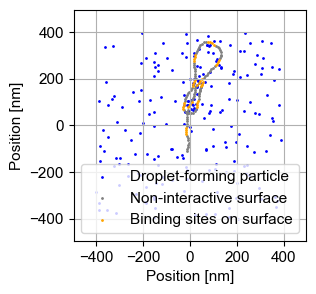

In [6]:
plt.figure(figsize=(3,3))
axis_l1=[-400,-200,0,200,400]
ax1= plt.subplot()

color_ch1="blue"
color_ch2="grey"
color_ch3="orange"

ax1.scatter([-450,-450,450,450],[-450,450,450,-450],s=30,color="white") #make sure that same size for plots

ax1.scatter(slice_coords_test[:,0],slice_coords_test[:,1],s=1,color=color_ch1,label="Droplet-forming particle")

ax1.scatter(slice_coords_test2[:,0],slice_coords_test2[:,1],s=1,color=color_ch2,label="Non-interactive surface")

ax1.scatter(slice_coords_test3[:,0],slice_coords_test3[:,1],s=1,color=color_ch3,label="Binding sites on surface")

plt.legend(loc="lower center",prop={'family': 'Arial','size': 11})
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel("Position [nm]",fontname = "Arial",fontsize=11)
plt.xlabel("Position [nm]",fontname = "Arial",fontsize=11)
plt.grid()

In [358]:
#plot 2D slices 
def plot_2D_slices(folder,name,add_num,rep_num,t_eval,slice_size,axis_slice,save_folder,save_fig,figsize=(3,3),axis_l1=[-400,-200,0,200,400],s_particle=1,ax_label="Position [nm]"):
    #folder: folder in which to look for sims
    #name: name of sim= name+str(add_num[i]+rep_num[j])+.h5
    #add_num: first part of name of sim, corresponding the the condition
    #rep_num: second part of name, add integer corresponding to the repeats for each condition
    #t_eval: time step to evaluate
    #slice_size: slice starting from 0 with +/- extension=slice_size will be used
    #axis_slice: which axis to use for slice projection
    #save_folder: folder in which to save projection
    #save_fig: whether to save figures
    for i in add_num:
        print("######################")
        print("Condition:",i)
        print("######################")
        for j in rep_num:
            file_name=folder+name+str(int(i)+int(j))+".h5"
            print(file_name)
            traj_db1=readdy.Trajectory(file_name)

            times,types,ids,part_positions=traj_db1.read_observable_particles()
            
            

            slice_coords_test=select_slice(part_positions_load=part_positions,types_load=types,type_particle=0,slice_start=-slice_size,slice_stop=slice_size,coord=axis_slice,dt=t_eval)


            slice_coords_test2=select_slice(part_positions_load=part_positions,types_load=types,type_particle=2,slice_start=-slice_size,slice_stop=slice_size,coord=axis_slice,dt=t_eval)


            slice_coords_test3=select_slice(part_positions_load=part_positions,types_load=types,type_particle=3,slice_start=-slice_size,slice_stop=slice_size,coord=axis_slice,dt=t_eval)
            
            plt.figure(figsize=figsize)
            #axis_l1=axis_l1
            ax1= plt.subplot()

            color_ch1="blue"
            color_ch2="grey"
            color_ch3="orange"

            #ax1.scatter([-450,-450,450,450],[-450,450,450,-450],s=30,color="white") #make sure that same size for plots
            
            ax1.scatter([-500,-500,500,500],[-500,500,500,-500],s=30,color="white")
            
            ax1.scatter(slice_coords_test[:,0],slice_coords_test[:,1],s=s_particle,color=color_ch1, marker='o',linewidths=0,label="Droplet-forming particle")
            
            try:
                ax1.scatter(slice_coords_test2[:,0],slice_coords_test2[:,1],s=s_particle,color=color_ch2, marker='o',linewidths=0,label="Non-interactive surface")

                ax1.scatter(slice_coords_test3[:,0],slice_coords_test3[:,1],s=s_particle,color=color_ch3, marker='o',linewidths=0,label="Binding sites on surface")
            except:
                pass
            #plt.legend(loc="lower center",prop={'family': 'Arial','size': 11})
            plt.xticks(axis_l1,axis_l1,fontname = "Arial",fontsize=11)
            plt.yticks(axis_l1,axis_l1,fontname = "Arial",fontsize=11)
            plt.ylabel(ax_label,fontname = "Arial",fontsize=11)
            plt.xlabel(ax_label,fontname = "Arial",fontsize=11)
            plt.grid()
            
            if save_fig==True:
                name_save=save_folder +name+str(int(i)+int(j))+".h5"+"_slice.png"
                plt.savefig(name_save,bbox_inches="tight",format="png",dpi=1000)
                plt.show()
            if save_fig==False:
                
                plt.show()
        

######################
Condition: 51100
######################
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51109.h5


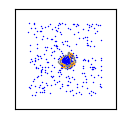

In [359]:
#plot slices with surface
add_num_s1=[51100] #[5300,5500,5700,5900,51100]
rep_num_s1=[9] #[0,1,2,3,4,5,6,7,8,9]
folder_s1="/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/"
name_s1="effective_droplet_"
save_folder_s1="/home/aaron/phd/files_effective_droplet_1/figures_surface/images_slices/" #slices/
#,figsize=(3,3),axis_l1=[-400,-200,0,200,400],s_particle=1
plot_2D_slices(folder=folder_s1,name=name_s1,add_num=add_num_s1,rep_num=rep_num_s1,t_eval=-1,slice_size=10000,axis_slice=2,save_folder=save_folder_s1,save_fig=True,figsize=(1.3,1.3),axis_l1=[],s_particle=1,ax_label=None)

In [ ]:
#select for slices, with surface
#90:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5308.h5

#180:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5507.h5

#270:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5704.h5

#360:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5900.h5

#450:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51107.h5

######################
Condition: 1100
######################
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1109.h5


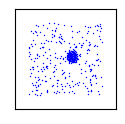

In [361]:
#plot slices without surface
add_num_s2=[1100] #[300,500,700,900,1100]
rep_num_s2=[9]  #[0,1,2,3,4,5,6,7,8,9]
folder_s2="/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/"
name_s2="effective_droplet_"
save_folder_s2="/home/aaron/phd/files_effective_droplet_1/figures_surface/images_slices/"  #slices/

plot_2D_slices(folder=folder_s2,name=name_s2,add_num=add_num_s2,rep_num=rep_num_s2,t_eval=-1,slice_size=10000,axis_slice=2,save_folder=save_folder_s2,save_fig=True,figsize=(1.3,1.3),axis_l1=[],s_particle=1,ax_label=None)

In [ ]:
#select for slices, no surface
#90:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_301.h5

#180:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_501.h5

#270:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_706.h5

#360:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_900.h5

#450:
#/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1101.h5

# DB-scan detected clusters 

# Influence of surface on detection of droplets with DBSCAN

In [7]:


#get a list [ [ [cond 1, coords rep 1] , [cond 1, coords rep 2],... ],[ [cond 2, coords rep 1] , [cond 2, coords rep 2],... ],...]
def get_array_of_coords(folder,name,add_num,rep_num, name_particle,t_eval):
    #folder: folder in which to look for sims
    #name: name of sim= name+str(add_num[i]+rep_num[j])+.h5
    #add_num: first part of name of sim, corresponding the the condition
    #rep_num: second part of name, add integer corresponding to the repeats for each condition
    #name_particle: the name of the particle whose coordinates are selected
    #t_eval: time step to evaluate
    list_of_coords_of_repeats=[] #each of the add_num entries contains tot_num arrays of coordinates
    for i in add_num:
        coords_repeats=[]
        
        for j in rep_num:
            file_name=folder+name+str(int(i)+int(j))+".h5"
            print(file_name)
            traj_db1=readdy.Trajectory(file_name)

            times_db1,types_db1,ids_db1,part_positions_db1=traj_db1.read_observable_particles()
            
            #iterate over every particle, only choose specific particle
            P_n = len(part_positions_db1[t_eval])
            part_positions_db1f=[]
            for p in range(P_n):
                if traj_db1.species_name(types_db1[t_eval][p]) ==name_particle:
                    part_positions_db1f.append(part_positions_db1[t_eval][p])
            
            X=np.asarray(part_positions_db1f)
            coords_repeats.append(X)
        coords_repeats =np.array(coords_repeats) 
        list_of_coords_of_repeats.append(coords_repeats)
    return list_of_coords_of_repeats

#based on get_array_of_coords but use list of input particle names
#get a list [ [ [cond 1, coords rep 1] , [cond 1, coords rep 2],... ],[ [cond 2, coords rep 1] , [cond 2, coords rep 2],... ],...]
def get_array_of_coords2(folder,name,add_num,rep_num, list_name_particles,t_eval):
    #folder: folder in which to look for sims
    #name: name of sim= name+str(add_num[i]+rep_num[j])+.h5
    #add_num: first part of name of sim, corresponding the the condition
    #rep_num: second part of name, add integer corresponding to the repeats for each condition
    #list_name_particles: list of the names of the particles whose coordinates are selected
    #t_eval: time step to evaluate
    list_of_coords_of_repeats=[] #each of the add_num entries contains tot_num arrays of coordinates
    for i in add_num:
        coords_repeats=[]
        
        for j in rep_num:
            file_name=folder+name+str(int(i)+int(j))+".h5"
            print(file_name)
            traj_db1=readdy.Trajectory(file_name)

            times_db1,types_db1,ids_db1,part_positions_db1=traj_db1.read_observable_particles()
            
            #iterate over every particle, only choose specific particle
            P_n = len(part_positions_db1[t_eval])
            part_positions_db1f=[]
            for p in range(P_n):
                if traj_db1.species_name(types_db1[t_eval][p]) in list_name_particles:
                    part_positions_db1f.append(part_positions_db1[t_eval][p])
            
            X=np.asarray(part_positions_db1f)
            coords_repeats.append(X)
        coords_repeats =np.array(coords_repeats) 
        list_of_coords_of_repeats.append(coords_repeats)
    return list_of_coords_of_repeats


#version without convex hull for concentration
'''#run dbscan return total number of points in clusters, number of clusters, and average points per cluster
def run_dbscan(data, eps=40, min_samples=10):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(data)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    n_points_in_clusters = len(data) - n_noise
    points_per_cluster = [list(labels).count(i) for i in range(n_clusters)]
    return n_points_in_clusters, n_clusters, points_per_cluster

#apply run_dbscan to repeats in parallel, average over repeats, get mean and std error of mean
def calculate_statistics(arrays, eps=40, min_samples=10):
    results = Parallel(n_jobs=-1)(delayed(run_dbscan)(data, eps, min_samples) for data in arrays)
    
    points_in_clusters = [result[0] for result in results]
    n_clusters_list = [result[1] for result in results]
    points_per_cluster_list = [np.mean(result[2]) for result in results if result[2]]
    
    mean_points_in_clusters = np.mean(points_in_clusters)
    sem_points_in_clusters = sem(points_in_clusters)
    
    mean_n_clusters = np.mean(n_clusters_list)
    sem_n_clusters = sem(n_clusters_list)
    
    mean_points_per_cluster = np.mean(points_per_cluster_list)
    sem_points_per_cluster = sem(points_per_cluster_list)
    
    return (mean_points_in_clusters, sem_points_in_clusters,
            mean_n_clusters, sem_n_clusters,
            mean_points_per_cluster, sem_points_per_cluster)'''


#version with convex hull for volume

#run dbscan return total number of points in clusters, number of clusters, and average points per cluster
def run_dbscan(data, eps=40, min_samples=10,radius_expand=10):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(data)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    n_points_in_clusters = len(data) - n_noise
    points_per_cluster = [list(labels).count(i) for i in range(n_clusters)]
    
    unique_labels = set(labels)
    cluster_conc=[]
    for label in unique_labels:
        if label != -1:  # Ignore noise points
            cluster_points = data[labels == label]
            num_points = len(cluster_points)
            
            
            # Calculate the convex hull volume of the cluster and use it for conc
            #hull = ConvexHull(cluster_points)
            hull=expand_convex_hull_3d(points=cluster_points, radius=radius_expand)
            hull_volume = hull.volume
            
            #hull_volume=minimum_bounding_box(cluster_points,radius_expand)[1]
            
            cluster_conc_e=num_points/hull_volume
            
            #get nearest neighbours and use inverse of mean distance
            #nbrs = NearestNeighbors(n_neighbors=min_samples, algorithm='ball_tree').fit(cluster_points)
            #distances, indices = nbrs.kneighbors(cluster_points)
            #cluster_conc_e = np.mean(1 / np.mean(distances[:, 1:], axis=1))
            
            #print("hull volume",hull_volume)
            cluster_conc.append(cluster_conc_e)

    return n_points_in_clusters, n_clusters, points_per_cluster, cluster_conc

#apply run_dbscan to repeats in parallel, average over repeats, get mean and std error of mean
def calculate_statistics(arrays, eps=40, min_samples=10,radius_expand=10):
    results = Parallel(n_jobs=-1)(delayed(run_dbscan)(data, eps, min_samples,radius_expand) for data in arrays)
    
    points_in_clusters = [result[0] for result in results]
    n_clusters_list = [result[1] for result in results]
    points_per_cluster_list = [np.mean(result[2]) for result in results if result[2]]
    cluster_conc_list= [np.mean(result[3]) for result in results if result[3]]
    
    mean_points_in_clusters = np.mean(points_in_clusters)
    sem_points_in_clusters = sem(points_in_clusters)
    
    mean_n_clusters = np.mean(n_clusters_list)
    sem_n_clusters = sem(n_clusters_list)
    
    mean_points_per_cluster = np.mean(points_per_cluster_list)
    sem_points_per_cluster = sem(points_per_cluster_list)
    
    mean_cluster_conc=np.mean(cluster_conc_list)
    sem_cluster_conc=sem(cluster_conc_list)
    
    return (mean_points_in_clusters, sem_points_in_clusters,
            mean_n_clusters, sem_n_clusters,
            mean_points_per_cluster, sem_points_per_cluster,
            mean_cluster_conc,sem_cluster_conc)



#expand convex hull to account for dimension of particles
def expand_convex_hull(points, radius):
    # Calculate the convex hull
    hull = ConvexHull(points)
    
    # Get the vertices of the convex hull
    hull_points = points[hull.vertices]
    
    # Expand the convex hull by the radius
    expanded_hull_points = []
    for point in hull_points:
        for angle in np.linspace(0, 2 * np.pi, num=36):
            expanded_point = point + radius * np.array([np.cos(angle), np.sin(angle)])
            expanded_hull_points.append(expanded_point)
    
    # Calculate the convex hull of the expanded points
    expanded_hull = ConvexHull(expanded_hull_points)
    
    return expanded_hull

#expand convex hull to account for dimension of particles in 3D
def expand_convex_hull_3d(points, radius):
    # Calculate the convex hull
    hull = ConvexHull(points)
    
    # Get the vertices of the convex hull
    hull_points = points[hull.vertices]
    
    # Expand the convex hull by the radius
    expanded_hull_points = []
    for point in hull_points:
        for theta in np.linspace(0, 2 * np.pi, num=36):
            for phi in np.linspace(0, np.pi, num=18):
                expanded_point = point + radius * np.array([
                    np.sin(phi) * np.cos(theta),
                    np.sin(phi) * np.sin(theta),
                    np.cos(phi)
                ])
                expanded_hull_points.append(expanded_point)
                
    # Calculate the convex hull of the expanded points
    expanded_hull = ConvexHull(expanded_hull_points)
    #print(len(expanded_hull_points))
    return expanded_hull


def minimum_bounding_box(points, r):
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    #print(hull.volume)
    
    # Calculate the covariance matrix and its eigenvalues and eigenvectors
    cov_matrix = np.cov(hull_points, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Rotate the points to align with the principal components
    rotated_points = np.dot(hull_points, eigenvectors)
    
    # Find the minimum and maximum coordinates along each axis
    min_coords = np.min(rotated_points, axis=0)
    max_coords = np.max(rotated_points, axis=0)
    
    # Expand the bounding box by 2r along each dimension
    min_coords -= r
    max_coords += r
    
    # Calculate the dimensions of the bounding box
    dimensions = max_coords - min_coords
    
    # Calculate the volume of the bounding box
    volume = np.prod(dimensions)
    
    # Create the corners of the bounding box
    corners = np.array([[min_coords[0], min_coords[1], min_coords[2]],
                        [max_coords[0], min_coords[1], min_coords[2]],
                        [max_coords[0], max_coords[1], min_coords[2]],
                        [min_coords[0], max_coords[1], min_coords[2]],
                        [min_coords[0], min_coords[1], max_coords[2]],
                        [max_coords[0], min_coords[1], max_coords[2]],
                        [max_coords[0], max_coords[1], max_coords[2]],
                        [min_coords[0], max_coords[1], max_coords[2]]])
    
    # Rotate the corners back to the original coordinate system
    corners = np.dot(corners, eigenvectors.T)
    
    return dimensions, volume, corners

# Test DB scan and extension of convex hull to account for particle radius

Concentration of points in each cluster:
Cluster 0: 8.771773048602673 points per unit volume
Cluster 1: 6.989028885041569 points per unit volume
Cluster 2: 7.1052479857525555 points per unit volume


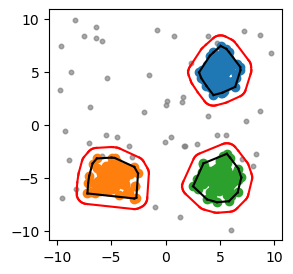

In [8]:

np.random.seed(42)

# Generate three clusters of points
cluster_1 = np.random.randn(100, 2) + np.array([5, 5])
cluster_2 = np.random.randn(100, 2) + np.array([-5, -5])
cluster_3 = np.random.randn(100, 2) + np.array([5, -5])

# Generate background noise
noise = np.random.uniform(low=-10, high=10, size=(50, 2))

# Combine the clusters and noise into one dataset
data = np.vstack([cluster_1, cluster_2, cluster_3, noise])


# Sample data and known diameter of spherical particles
data3 =data # np.random.randn(100, 2) + np.array([0, 5])#np.array([[1, 2], [2, 2], [3, 3], [8, 8], [8, 9], [25, 80]])
diameter = 1.0  # Example diameter of spherical particles

# Apply DBSCAN to the data
eps = 1.5
min_samples = 2
db = DBSCAN(eps=1, min_samples=10).fit(data3)
labels = db.labels_

# Calculate the volume of a single spherical particle
radius = diameter / 2
volume_of_particle = (4/3) * np.pi * (radius ** 3)

# Calculate the concentration of points in each cluster using the convex hull volume
unique_labels = set(labels)
concentration = {}
plt.figure(figsize=(3,3))
for label in unique_labels:
    if label != -1:  # Ignore noise points
        cluster_points = data3[labels == label]
        num_points = len(cluster_points)
        #plt.figure(figsize=(3,3))
        # Calculate the convex hull volume of the cluster
        if len(cluster_points) > 3:  # Convex hull requires at least 4 points in 3D space
            hull = ConvexHull(cluster_points)
            #hull=expand_hull(cluster_points,5)
            hull_volume = hull.volume
            expanded_hull=expand_convex_hull(cluster_points,1)
            
            # Plot the convex hull
            plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.3,color="grey")
            plt.plot(cluster_points[:,0], cluster_points[:,1], 'o')
            for simplex in hull.simplices:
                plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k-')
                
            for simplex in expanded_hull.simplices:
                plt.plot(expanded_hull.points[simplex, 0], expanded_hull.points[simplex, 1], 'r-')

        else:
            hull_volume = np.prod(np.max(cluster_points, axis=0) - np.min(cluster_points, axis=0))
        
        concentration[label] = num_points / hull_volume

print("Concentration of points in each cluster:")
for label, conc in concentration.items():
    print(f"Cluster {label}: {conc} points per unit volume")

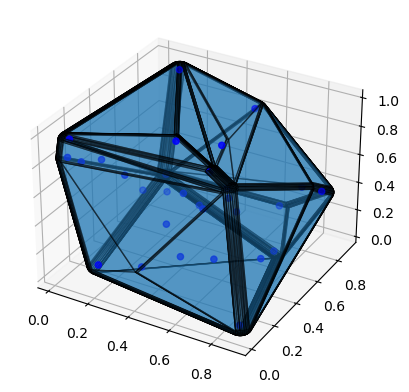

In [9]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# Example usage
points = np.random.rand(30, 3)  # Random cloud of points in 3D space
radius = 0.05  # Radius of each point

expanded_hull = expand_convex_hull_3d(points, radius)

# Plot the original points and the expanded convex hull
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='b', marker='o')

# Plot the expanded convex hull
for simplex in expanded_hull.simplices:
    tri = Poly3DCollection([expanded_hull.points[simplex]], alpha=0.5, edgecolor='k')
    ax.add_collection3d(tri)

plt.show()

# Load and evaluate simulation data

In [10]:
#Generate coordinate list of conditions and repeats
#With surface

add_num_1=[5200,5300,5400,5500,5600,5700,5800,5900,51000,51100]
rep_num_1=[0,1,2,3,4,5,6,7,8,9]
folder_1="/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/"
name_1="effective_droplet_"

coords_cond_1=get_array_of_coords(folder=folder_1,name=name_1,add_num=add_num_1,rep_num=rep_num_1, name_particle="core",t_eval=-1)

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5200.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5201.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5202.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5203.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5204.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5205.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5206.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5207.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5208.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5209.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/eff

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51009.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51100.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51101.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51102.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51103.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51104.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51105.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51106.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51107.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51108.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surfac

In [11]:
%%time
#apply DBSCAN in parallel to repeats of each condition

all_part_in_drop_3=[]
all_part_in_drop_std_e_3=[]
drop_num_3=[]
drop_num_std_e_3=[]
part_in_drop_3=[]
part_in_drop_std_e_3=[]
conc_in_drop_3=[]
conc_in_drop_std_e_3=[]

for i in range(len(coords_cond_1)):

    all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=coords_cond_1[i], eps=40, min_samples=10)
    
    all_part_in_drop_3.append(all_part_in_drop_x)
    all_part_in_drop_std_e_3.append(all_part_in_drop_std_e_x)
    drop_num_3.append(drop_num_x)
    drop_num_std_e_3.append(drop_num_std_e_x)
    part_in_drop_3.append(part_in_drop_x)
    part_in_drop_std_e_3.append(part_in_drop_std_e_x)
    conc_in_drop_3.append(conc_in_drop_x)
    conc_in_drop_std_e_3.append(conc_in_drop_std_e_x)
    

/home/aaron/miniconda3/envs/general2/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aaron/miniconda3/envs/general2/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/aaron/miniconda3/envs/general2/lib/python3.9/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aaron/miniconda3/envs/general2/lib/python3.9/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/aaron/miniconda3/envs/general2/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


CPU times: user 112 ms, sys: 204 ms, total: 316 ms
Wall time: 2.52 s


In [12]:
#Generate coordinate list of conditions and repeats
#No surface

add_num_2=[200,300,400,500,600,700,800,900,1000,1100]
rep_num_2=[0,1,2,3,4,5,6,7,8,9]
folder_2="/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/"
name_2="effective_droplet_"

coords_cond_2=get_array_of_coords(folder=folder_2,name=name_2,add_num=add_num_2,rep_num=rep_num_2, name_particle="core",t_eval=-1)

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_200.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_201.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_202.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_203.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_204.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_205.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_206.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_207.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_208.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_209.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_dro

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1009.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1100.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1101.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1102.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1103.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1104.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1105.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1106.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1107.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_1108.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/eff

In [13]:
%%time
#apply DBSCAN in parallel to repeats of each condition

all_part_in_drop_4=[]
all_part_in_drop_std_e_4=[]
drop_num_4=[]
drop_num_std_e_4=[]
part_in_drop_4=[]
part_in_drop_std_e_4=[]
conc_in_drop_4=[]
conc_in_drop_std_e_4=[]

for i in range(len(coords_cond_2)):

    all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=coords_cond_2[i], eps=40, min_samples=10)
    
    all_part_in_drop_4.append(all_part_in_drop_x)
    all_part_in_drop_std_e_4.append(all_part_in_drop_std_e_x)
    drop_num_4.append(drop_num_x)
    drop_num_std_e_4.append(drop_num_std_e_x)
    part_in_drop_4.append(part_in_drop_x)
    part_in_drop_std_e_4.append(part_in_drop_std_e_x)
    conc_in_drop_4.append(conc_in_drop_x)
    conc_in_drop_std_e_4.append(conc_in_drop_std_e_x)


CPU times: user 56.6 ms, sys: 16.6 ms, total: 73.1 ms
Wall time: 786 ms


In [14]:
all_part_in_drop_4

[0.0, 0.0, 0.0, 0.0, 0.0, 1.2, 29.8, 77.7, 124.7, 199.6]

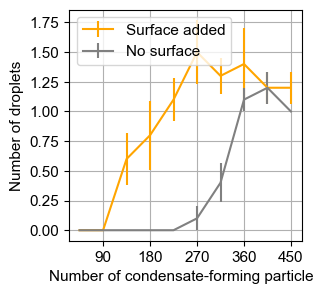

In [15]:
#fig_size=3
font_size=11 #9
plt.figure(figsize=(3,3)) #(5,3)
#plt.figure(figsize=(fig_size,fig_size))
num_y_motifs=[45,90,135,180,225,270,315,360,405,450]
num_y_motifs_2=[45,135,225,315,405]
num_y_motifs_2=[90,180,270,360,450]
ax1= plt.subplot()
ax1.errorbar(num_y_motifs,drop_num_3,yerr=drop_num_std_e_3,label="Surface added",color="orange")
ax1.errorbar(num_y_motifs,drop_num_4,yerr=drop_num_std_e_4,label="No surface",color="grey")
plt.legend(prop={'family': 'Arial','size': font_size})
plt.xticks(num_y_motifs_2,num_y_motifs_2,fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)
plt.ylabel("Number of droplets",fontname = "Arial",fontsize=font_size)
#plt.xlabel("Number of droplet-forming particles",fontname = "Arial",fontsize=font_size)
plt.xlabel("Number of condensate-forming particles",fontname = "Arial",fontsize=font_size)

plt.grid()

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/number_droplets_surf_t_m1_4.pdf",bbox_inches="tight",format="pdf")


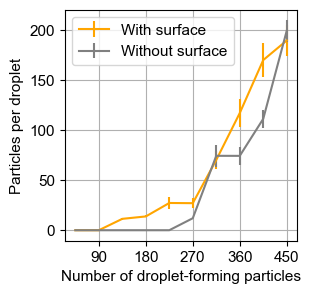

In [16]:
plt.figure(figsize=(3,3))
num_y_motifs=[45,90,135,180,225,270,315,360,405,450]
num_y_motifs_2=[45,135,225,315,405]
num_y_motifs_2=[90,180,270,360,450]
ax1= plt.subplot()
ax1.errorbar(num_y_motifs,np.nan_to_num(part_in_drop_3, nan=0.0),np.nan_to_num(part_in_drop_std_e_3, nan=0.0),label="With surface",color="orange")
ax1.errorbar(num_y_motifs,np.nan_to_num(part_in_drop_4, nan=0.0),np.nan_to_num(part_in_drop_std_e_4, nan=0.0),label="Without surface",color="grey")
plt.legend(prop={'family': 'Arial','size': 11})
plt.xticks(num_y_motifs_2,num_y_motifs_2,fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel("Particles per droplet",fontname = "Arial",fontsize=11)
plt.xlabel("Number of droplet-forming particles",fontname = "Arial",fontsize=11)
plt.grid()

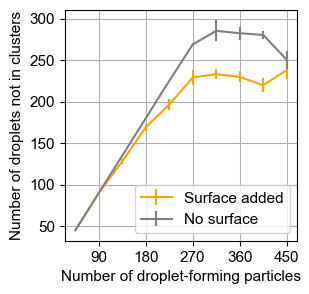

In [17]:
fig_size=3
font_size=11 #9
#plt.figure(figsize=(3,3))
plt.figure(figsize=(fig_size,fig_size))
num_y_motifs=[45,90,135,180,225,270,315,360,405,450]
num_y_motifs_2=[45,135,225,315,405]
num_y_motifs_2=[90,180,270,360,450]

all_part_not_in_drop_3=np.array(num_y_motifs)-np.array(all_part_in_drop_3)
all_part_not_in_drop_4=np.array(num_y_motifs)-np.array(all_part_in_drop_4)

ax1= plt.subplot()
ax1.errorbar(num_y_motifs,all_part_not_in_drop_3,yerr=all_part_in_drop_std_e_3,label="Surface added",color="orange")
ax1.errorbar(num_y_motifs,all_part_not_in_drop_4,yerr=all_part_in_drop_std_e_4,label="No surface",color="grey")
plt.legend(prop={'family': 'Arial','size': font_size})
plt.xticks(num_y_motifs_2,num_y_motifs_2,fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)
plt.ylabel("Number of droplets not in clusters",fontname = "Arial",fontsize=font_size)
plt.xlabel("Number of droplet-forming particles",fontname = "Arial",fontsize=font_size)
plt.grid()

## Assume fixed packing density for dense phase 

In [18]:
#use particle and box volume to calculate c_dense and c_dilute

V_particle=4/3 *np.pi * 10**3  

#effectively, spheres that are closely packed take up a volume 1/0.74 larger than just the number of spheres times the sphere volume
#https://en.wikipedia.org/wiki/Close-packing_of_equal_spheres
#any rescaling of the sphere volume will only shift the y-axis

V_particle=V_particle*1/0.74 

V_box=1000**3



######
print("Max % difference between V_box and V_dilute:",V_particle*450 /V_box *100)

Max % difference between V_box and V_dilute: 0.2547237286694427


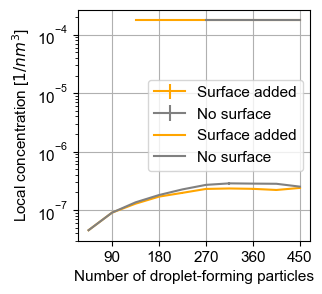

In [19]:
fig_size=3
font_size=11 #9
#plt.figure(figsize=(3,3))
plt.figure(figsize=(fig_size,fig_size))
num_y_motifs=[45,90,135,180,225,270,315,360,405,450]
num_y_motifs_2=[45,135,225,315,405]
num_y_motifs_2=[90,180,270,360,450] 

#c_dense=N_in_drop/(N_in_drop*V_particle * 1/highest packing density for spheres=0.74) #https://en.wikipedia.org/wiki/Close-packing_of_equal_spheres

#c_dilute=N_not_in_drop/V_dilute

#N_not_in_drop=N_tot-N_in_drop
#V_dilute=V_tot-N_in_drop*V_particle*0.74

#error prop.:
#d_c_dilute=c_dilute*np.sqrt((d_V_dilute/V_dilute)^2 + (d_N_not_in_drop/N_not_in_drop)^2)
#d_V_dilute=V_part*d_N_in_drop
#d_N_not_in_drop=d_N_in_drop


all_part_not_in_drop_3=np.array(num_y_motifs)-np.array(all_part_in_drop_3)
all_part_not_in_drop_4=np.array(num_y_motifs)-np.array(all_part_in_drop_4)

V_dilute_3=V_box-np.array(all_part_in_drop_3)*V_particle 
c_dilute_3=all_part_not_in_drop_3/V_dilute_3

V_dilute_4=V_box-np.array(all_part_in_drop_4)*V_particle 
c_dilute_4=all_part_not_in_drop_4/V_dilute_4

d_c_dilute_3=c_dilute_3 * np.sqrt( (V_particle*np.array(all_part_in_drop_std_e_3)/V_dilute_3)**2 +(np.array(all_part_in_drop_std_e_3)/all_part_not_in_drop_3)**2 )
d_c_dilute_4=c_dilute_4 * np.sqrt( (V_particle*np.array(all_part_in_drop_std_e_4)/V_dilute_4)**2 +(np.array(all_part_in_drop_std_e_4)/all_part_not_in_drop_4)**2 )

c_dense_3=[]
num_y_motifs_dense_3=[]
for i in range(len(all_part_in_drop_3)):
    if all_part_in_drop_3[i]!=0:
        c_dense_3.append(1/V_particle)
        num_y_motifs_dense_3.append(num_y_motifs[i])

c_dense_4=[]
num_y_motifs_dense_4=[]
for i in range(len(all_part_in_drop_4)):
    if all_part_in_drop_4[i]!=0:
        c_dense_4.append(1/V_particle)
        num_y_motifs_dense_4.append(num_y_motifs[i])
        
ax1= plt.subplot()
ax1.errorbar(num_y_motifs,c_dilute_3,yerr=d_c_dilute_3,label="Surface added",color="orange")
ax1.errorbar(num_y_motifs,c_dilute_4,yerr=d_c_dilute_4,label="No surface",color="grey")

ax1.errorbar(num_y_motifs_dense_3,c_dense_3,label="Surface added",color="orange")
ax1.errorbar(num_y_motifs_dense_4,c_dense_4,label="No surface",color="grey")


plt.legend(prop={'family': 'Arial','size': font_size})
plt.xticks(num_y_motifs_2,num_y_motifs_2,fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)
plt.ylabel("Local concentration [$1/nm^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel("Number of droplet-forming particles",fontname = "Arial",fontsize=font_size)
plt.yscale("log")
plt.grid()

Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

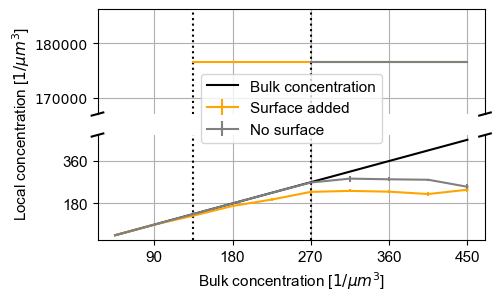

In [20]:
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))


c_bulk=np.array(np.array(num_y_motifs)/V_box) 
c_bulk_for_dense_3=np.array(num_y_motifs_dense_3)/V_box
c_bulk_for_dense_4=np.array(num_y_motifs_dense_4)/V_box

ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="black")
ax2.errorbar(c_bulk*10**9,c_dilute_3*10**9,yerr=d_c_dilute_3*10**9,label="Surface added",color="orange")
ax2.errorbar(c_bulk*10**9,c_dilute_4*10**9,yerr=d_c_dilute_4*10**9,label="No surface",color="grey")


ax1.errorbar(c_bulk_for_dense_3*10**9,np.array(c_dense_3)*10**9,label="Surface added",color="orange")
ax1.errorbar(c_bulk_for_dense_4*10**9,np.array(c_dense_4)*10**9,label="No surface",color="grey")

ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

#plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
#ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout


conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_3.pdf",bbox_inches="tight",format="pdf")


## Calculate dense phase concentration with convex hull 

Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

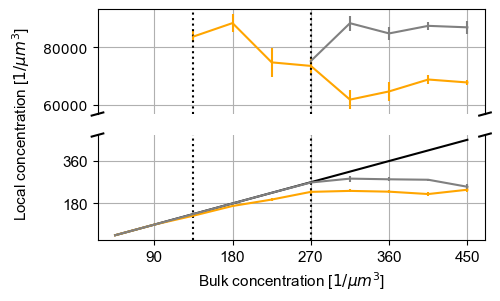

In [21]:
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))


c_bulk=np.array(np.array(num_y_motifs)/V_box) 
c_bulk_for_dense_3= np.array(num_y_motifs_dense_3)/V_box
c_bulk_for_dense_4=np.array(num_y_motifs_dense_4)/V_box

ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="black")
ax2.errorbar(c_bulk*10**9,c_dilute_3*10**9,yerr=d_c_dilute_3*10**9,label="Surface added",color="orange")
ax2.errorbar(c_bulk*10**9,c_dilute_4*10**9,yerr=d_c_dilute_4*10**9,label="No surface",color="grey")

#fixed concentration inside droplets
#ax1.errorbar(c_bulk_for_dense_3*10**9,np.array(c_dense_3)*10**9,label="Surface added",color="orange")
#ax1.errorbar(c_bulk_for_dense_4*10**9,np.array(c_dense_4)*10**9,label="No surface",color="grey")

#concentration in droplets from convex hull
conc_in_drop_3_nn=np.array(conc_in_drop_3)[~np.isnan(np.array(conc_in_drop_3))]
conc_in_drop_4_nn=np.array(conc_in_drop_4)[~np.isnan(np.array(conc_in_drop_4))]

conc_in_drop_std_e_3_nn=[]
conc_in_drop_std_e_4_nn=[]
for i in range(len(conc_in_drop_3)): #get ste_d for entries that have multiple droplets 
    if conc_in_drop_3[i]>0:
        if conc_in_drop_std_e_3[i]>0: #in std_e array, can not distinguish no droplets and only 1 droplet
            conc_in_drop_std_e_3_nn.append(conc_in_drop_std_e_3[i])
        else: #case only one droplet detected, need value for std_e
            conc_in_drop_std_e_3_nn.append(0)
            
for i in range(len(conc_in_drop_4)): #get ste_d for entries that have multiple droplets 
    if conc_in_drop_4[i]>0:
        if conc_in_drop_std_e_4[i]>0: #in std_e array, can not distinguish no droplets and only 1 droplet
            conc_in_drop_std_e_4_nn.append(conc_in_drop_std_e_4[i])
        else: #case only one droplet detected, need value for std_e
            conc_in_drop_std_e_4_nn.append(0)  
            
conc_in_drop_std_e_3_nn=np.array(conc_in_drop_std_e_3_nn) 
conc_in_drop_std_e_4_nn=np.array(conc_in_drop_std_e_4_nn)         

#conc_in_drop_std_e_3_nn=np.array(conc_in_drop_std_e_3)[~np.isnan(np.array(conc_in_drop_std_e_3))]
#conc_in_drop_std_e_4_nn=np.array(conc_in_drop_std_e_4)[~np.isnan(np.array(conc_in_drop_std_e_4))]

ax1.errorbar(c_bulk_for_dense_3*10**9,conc_in_drop_3_nn*10**9,yerr=conc_in_drop_std_e_3_nn*10**9,label="Surface added",color="orange")
ax1.errorbar(c_bulk_for_dense_4*10**9,conc_in_drop_4_nn*10**9,yerr=conc_in_drop_std_e_4_nn*10**9,label="No surface",color="grey")



ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

##plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
#ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
##ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout


conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_3.pdf",bbox_inches="tight",format="pdf")


## Include limited resolution by increasing padding around vertices of convex hull around dense phase droplets

In [22]:
%%time
#apply DBSCAN in parallel to repeats of each condition

all_part_in_drop_3b=[]
all_part_in_drop_std_e_3b=[]
drop_num_3b=[]
drop_num_std_e_3b=[]
part_in_drop_3b=[]
part_in_drop_std_e_3b=[]
conc_in_drop_3b=[]
conc_in_drop_std_e_3b=[]

for i in range(len(coords_cond_1)):

    all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=coords_cond_1[i], eps=40, min_samples=10,radius_expand=20)
    #all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=gaussian_filter(coords_cond_1[i],1), eps=40, min_samples=10,radius_expand=20)

    all_part_in_drop_3b.append(all_part_in_drop_x)
    all_part_in_drop_std_e_3b.append(all_part_in_drop_std_e_x)
    drop_num_3b.append(drop_num_x)
    drop_num_std_e_3b.append(drop_num_std_e_x)
    part_in_drop_3b.append(part_in_drop_x)
    part_in_drop_std_e_3b.append(part_in_drop_std_e_x)
    conc_in_drop_3b.append(conc_in_drop_x)
    conc_in_drop_std_e_3b.append(conc_in_drop_std_e_x)

all_part_in_drop_4b=[]
all_part_in_drop_std_e_4b=[]
drop_num_4b=[]
drop_num_std_e_4b=[]
part_in_drop_4b=[]
part_in_drop_std_e_4b=[]
conc_in_drop_4b=[]
conc_in_drop_std_e_4b=[]

for i in range(len(coords_cond_2)):

    all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=coords_cond_2[i], eps=40, min_samples=10,radius_expand=20)
    #all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=gaussian_filter(coords_cond_2[i],1), eps=40, min_samples=10,radius_expand=20)

    all_part_in_drop_4b.append(all_part_in_drop_x)
    all_part_in_drop_std_e_4b.append(all_part_in_drop_std_e_x)
    drop_num_4b.append(drop_num_x)
    drop_num_std_e_4b.append(drop_num_std_e_x)
    part_in_drop_4b.append(part_in_drop_x)
    part_in_drop_std_e_4b.append(part_in_drop_std_e_x)
    conc_in_drop_4b.append(conc_in_drop_x)
    conc_in_drop_std_e_4b.append(conc_in_drop_std_e_x)

    

CPU times: user 143 ms, sys: 799 µs, total: 144 ms
Wall time: 2.08 s


Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

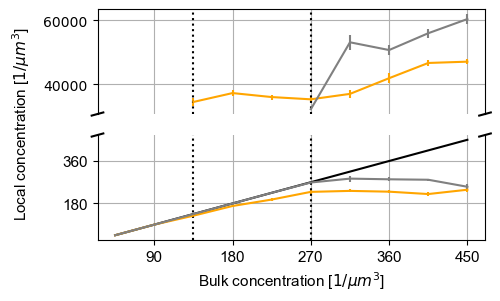

In [24]:
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))


c_bulk=np.array(np.array(num_y_motifs)/V_box) 
#c_bulk_for_dense_3b= np.array(num_y_motifs_dense_3b)/V_box
#c_bulk_for_dense_4b=np.array(num_y_motifs_dense_4b)/V_box

ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="black")
ax2.errorbar(c_bulk*10**9,c_dilute_3*10**9,yerr=d_c_dilute_3*10**9,label="Surface added",color="orange")
ax2.errorbar(c_bulk*10**9,c_dilute_4*10**9,yerr=d_c_dilute_4*10**9,label="No surface",color="grey")

#fixed concentration inside droplets
#ax1.errorbar(c_bulk_for_dense_3b*10**9,np.array(c_dense_3b)*10**9,label="Surface added",color="orange")
#ax1.errorbar(c_bulk_for_dense_4b*10**9,np.array(c_dense_4b)*10**9,label="No surface",color="grey")

#concentration in droplets from convex hull
conc_in_drop_3b_nn=np.array(conc_in_drop_3b)[~np.isnan(np.array(conc_in_drop_3b))]
conc_in_drop_4b_nn=np.array(conc_in_drop_4b)[~np.isnan(np.array(conc_in_drop_4b))]

conc_in_drop_std_e_3b_nn=[]
conc_in_drop_std_e_4b_nn=[]
for i in range(len(conc_in_drop_3b)): #get ste_d for entries that have multiple droplets 
    if conc_in_drop_3b[i]>0:
        if conc_in_drop_std_e_3b[i]>0: #in std_e array, can not distinguish no droplets and only 1 droplet
            conc_in_drop_std_e_3b_nn.append(conc_in_drop_std_e_3b[i])
        else: #case only one droplet detected, need value for std_e
            conc_in_drop_std_e_3b_nn.append(0)
            
for i in range(len(conc_in_drop_4b)): #get ste_d for entries that have multiple droplets 
    if conc_in_drop_4b[i]>0:
        if conc_in_drop_std_e_4b[i]>0: #in std_e array, can not distinguish no droplets and only 1 droplet
            conc_in_drop_std_e_4b_nn.append(conc_in_drop_std_e_4b[i])
        else: #case only one droplet detected, need value for std_e
            conc_in_drop_std_e_4b_nn.append(0)  
            
conc_in_drop_std_e_3b_nn=np.array(conc_in_drop_std_e_3b_nn) 
conc_in_drop_std_e_4b_nn=np.array(conc_in_drop_std_e_4b_nn)         

#conc_in_drop_std_e_3b_nn=np.array(conc_in_drop_std_e_3b)[~np.isnan(np.array(conc_in_drop_std_e_3b))]
#conc_in_drop_std_e_4b_nn=np.array(conc_in_drop_std_e_4b)[~np.isnan(np.array(conc_in_drop_std_e_4b))]

ax1.errorbar(c_bulk_for_dense_3*10**9,conc_in_drop_3b_nn*10**9,yerr=conc_in_drop_std_e_3b_nn*10**9,label="Surface added",color="orange")
ax1.errorbar(c_bulk_for_dense_4*10**9,conc_in_drop_4b_nn*10**9,yerr=conc_in_drop_std_e_4b_nn*10**9,label="No surface",color="grey")



ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

##plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
#ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
##ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout


conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_3b.pdf",bbox_inches="tight",format="pdf")


Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

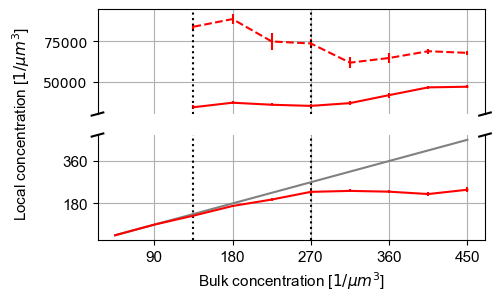

In [29]:
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))
ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="grey")
ax2.errorbar(c_bulk*10**9,c_dilute_3*10**9,yerr=d_c_dilute_3*10**9,label="Surface added",color="red")


ax1.errorbar(c_bulk_for_dense_3*10**9,conc_in_drop_3b_nn*10**9,yerr=conc_in_drop_std_e_3b_nn*10**9,label="Surface added",color="red",alpha=1)

ax1.errorbar(c_bulk_for_dense_3*10**9,conc_in_drop_3_nn*10**9,yerr=conc_in_drop_std_e_3_nn*10**9,color="red",fmt="--")



ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

##plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
#ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
##ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout


conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_3b.pdf",bbox_inches="tight",format="pdf")


Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

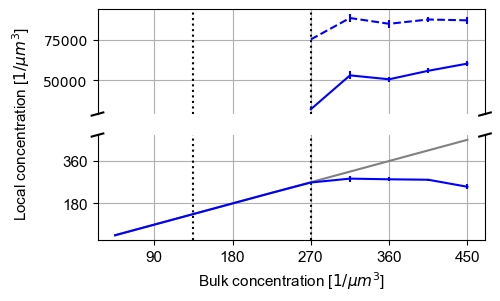

In [30]:
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))
ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="grey")
ax2.errorbar(c_bulk*10**9,c_dilute_4*10**9,yerr=d_c_dilute_4*10**9,label="No surface",color="blue")


ax1.errorbar(c_bulk_for_dense_4*10**9,conc_in_drop_4b_nn*10**9,yerr=conc_in_drop_std_e_4b_nn*10**9,label="No surface",color="blue",alpha=1)

ax1.errorbar(c_bulk_for_dense_4*10**9,conc_in_drop_4_nn*10**9,yerr=conc_in_drop_std_e_4_nn*10**9,color="blue",fmt="--")



ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

##plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
#ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
##ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout


conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_3b.pdf",bbox_inches="tight",format="pdf")


Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

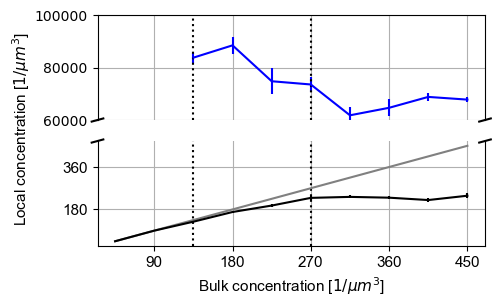

In [31]:
#With surface
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))  #(5,3)
ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="grey")
ax2.errorbar(c_bulk*10**9,c_dilute_3*10**9,yerr=d_c_dilute_3*10**9,label="Dilute phase",color="black")


ax1.errorbar(c_bulk_for_dense_3*10**9,conc_in_drop_3_nn*10**9,yerr=conc_in_drop_std_e_3_nn*10**9,color="blue",fmt="-",label="Droplet phase")

ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

##plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
#ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
##ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout

#ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout
conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

ax1.set_ylim(60000,100000)
plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_surf_4.pdf",bbox_inches="tight",format="pdf")


Text(-0.05, 0.5, 'Local concentration [$1/\\mu m^3$]')

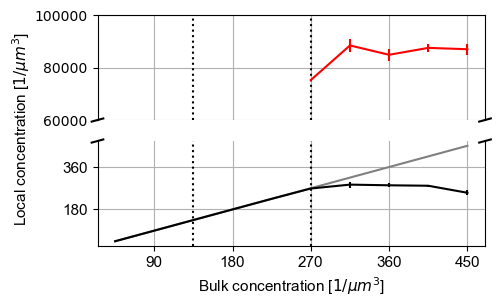

In [32]:
#Without surface
#fig_size=3
font_size=11 #9

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,3))
ax2.errorbar(c_bulk*10**9,c_bulk*10**9,label="Bulk concentration",color="grey")
#ax2.errorbar(c_bulk*10**9,c_dilute_3*10**9,yerr=d_c_dilute_3*10**9,label="Surface added",color="orange")
ax2.errorbar(c_bulk*10**9,c_dilute_4*10**9,yerr=d_c_dilute_4*10**9,color="black",label="Dilute phase")


ax1.errorbar(c_bulk_for_dense_4*10**9,conc_in_drop_4_nn*10**9,yerr=conc_in_drop_std_e_4_nn*10**9,color="red",fmt="-",label="Droplet phase")



ax1.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_3[0]*10**9, color='black', linestyle=':')

ax1.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')
ax2.axvline(c_bulk_for_dense_4[0]*10**9, color='black', linestyle=':')

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
#ax1.xaxis.tick_top()
ax1.tick_params(axis='x', which='both', length=0)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
#ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: '{:.1e}'.format(x)))
#ax1.set_ylim(175000,179500)     
#ax1.set_yticks([176000,178000],[176000,178000],fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)

ax2.xaxis.tick_bottom(  )

# Add diagonal lines to indicate the break in the y-axis
d = .015  # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

##plt.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5176, 0.8))
#ax2.legend(prop={'family': 'Arial','size': font_size}, bbox_to_anchor=(0.5,0.85)) #5x3 layout
##ax1.legend(prop={'family': 'Arial','size': font_size}) #5x3 layout

#ax1.legend(prop={'family': 'Arial','size': font_size})

conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

ax1.set_ylim(60000,100000)
plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(conc_bulk_label_y,conc_bulk_label_y,fontname = "Arial",fontsize=font_size)
#plt.ylabel("Concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
#plt.yscale("log")
ax1.grid()
ax2.grid()





#5x3 layout
fig.text(-0.05, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#3x3 layout
#fig.text(-0.2, 0.5, r'Local concentration [$1/\mu m^3$]', va='center', rotation='vertical',fontname = "Arial",fontsize=font_size)

#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/concentration_phases_no_surf_4.pdf",bbox_inches="tight",format="pdf")


# Turn simulation output into 3D image by using voxels and use them to calculate dense and dilute phase

In [33]:
#get coordinates of surface

#Generate coordinate list of conditions and repeats
#With surface

add_num_1=[5200,5300,5400,5500,5600,5700,5800,5900,51000,51100]
rep_num_1=[0,1,2,3,4,5,6,7,8,9]
folder_1="/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/"
name_1="effective_droplet_"

coords_surf_cond_1=get_array_of_coords2(folder=folder_1,name=name_1,add_num=add_num_1,rep_num=rep_num_1, list_name_particles=["surface_repulsion", "surface_attraction"],t_eval=-1)

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5200.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5201.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5202.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5203.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5204.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5205.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5206.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5207.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5208.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_5209.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/eff

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51009.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51100.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51101.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51102.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51103.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51104.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51105.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51106.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51107.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_test/effective_droplet_51108.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surfac

In [34]:
num_y_motifs=[45,90,135,180,225,270,315,360,405,450]
V_box=1000**3
font_size=11

conc_bulk_label_x=[90,180,270,360,450] 
conc_bulk_label_y=[180,360] 

In [35]:
def point_cloud_to_voxel(point_cloud, voxel_size, image_size):
    """
    Convert a 3D point cloud into a voxel-based 3D image by counting how many points fall into each voxel.
    
    Parameters:
    - point_cloud: A numpy array of shape (N, 3) representing the 3D point cloud.
    - voxel_size: The size of each voxel.
    - image_size: A tuple (x_size, y_size, z_size) representing the size of the 3D image.
    
    Returns:
    - A 3D numpy array representing the voxel-based 3D image.
    """
    # Calculate the shift needed to make all coordinates positive
    shift = np.array(image_size) / 2.0
    
    # Shift the point cloud coordinates
    shifted_point_cloud = point_cloud + shift
    
    # Calculate the number of voxels needed in each dimension
    num_voxels = np.ceil(np.array(image_size) / voxel_size).astype(int)
    
    # Initialize the 3D image with zeros
    voxel_image = np.zeros(num_voxels, dtype=int)
    
    # Calculate the voxel indices for each point in the point cloud
    voxel_indices = (shifted_point_cloud / voxel_size).astype(int)
    
    # Count the number of points in each voxel
    for idx in voxel_indices:
        voxel_image[tuple(idx)] += 1
    
    return voxel_image/450  #/ np.max(voxel_image)




from multiprocessing import Pool
def point_cloud_to_voxel_parallel(arrays, voxel_size, image_size):
    with Pool() as pool:
        results = pool.starmap(point_cloud_to_voxel, [(points, voxel_size, image_size) for points in arrays])
    return results






def image_thresholding(voxel_image):
    """
    Apply thresholding method to 3D voxel images and return the mean background, mean foreground, and overall mean intensity.
    
    Parameters:
    - voxel_image: A 3D numpy array representing the voxel-based 3D image.
    
    Returns:
    - mean_background: The mean intensity of the background.
    - mean_foreground: The mean intensity of the foreground.
    - overall_mean: The overall mean intensity of the image.
    """
    # Flatten the 3D image to a 1D array
    voxel_values = voxel_image.flatten()
    
    # Apply Otsu's method to find the threshold
    threshold = threshold_otsu(voxel_values)
    
    #use mean and std
    #threshold = np.mean(voxel_values)+2*np.std(voxel_values)
    
    # Separate the background and foreground based on the threshold
    background = voxel_values[voxel_values <= threshold]
    foreground = voxel_values[voxel_values > threshold]
    
    # Calculate the mean values
    mean_background = np.mean(background)
    mean_foreground = np.mean(foreground)
    overall_mean = np.mean(voxel_values)
    
    return mean_background, mean_foreground, overall_mean

def image_thresholding_parallel(voxel_images):
    with Pool() as pool:
        results = pool.starmap(image_thresholding, [(voxel_image,) for voxel_image in voxel_images])
        
    mean_background = [result[0] for result in results]
    mean_foreground = [result[1] for result in results]
    overall_mean    = [result[2] for result in results]
    return mean_background,mean_foreground,overall_mean





In [36]:
%%time
#With surface

voxel_image_cond_1=[]
voxel_image_cond_bl_1=[]
voxel_size=20
gf_w=3
for i in range(len(coords_cond_1)):
    voxel_image_cond_e=point_cloud_to_voxel_parallel(arrays=coords_cond_1[i], voxel_size=(voxel_size,voxel_size,voxel_size), image_size=(1000,1000,1000))
    voxel_image_cond_bl_e=gaussian_filter(point_cloud_to_voxel_parallel(arrays=coords_cond_1[i], voxel_size=(voxel_size,voxel_size,voxel_size), image_size=(1000,1000,1000)),gf_w)

    voxel_image_cond_1.append(voxel_image_cond_e)
    voxel_image_cond_bl_1.append(voxel_image_cond_bl_e)
    
voxel_image_cond_1=np.array(voxel_image_cond_1)
voxel_image_cond_bl_1=np.array(voxel_image_cond_bl_1)

CPU times: user 771 ms, sys: 2.18 s, total: 2.95 s
Wall time: 3.36 s


In [37]:
%%time
#Voxel based image for surface positions

voxel_image_surf_cond_1=[]
voxel_image_surf_cond_bl_1=[]

for i in range(len(coords_surf_cond_1)):
    voxel_image_surf_cond_e=point_cloud_to_voxel_parallel(arrays=coords_surf_cond_1[i], voxel_size=(voxel_size,voxel_size,voxel_size), image_size=(1000,1000,1000))
    voxel_image_surf_cond_bl_e=gaussian_filter(point_cloud_to_voxel_parallel(arrays=coords_surf_cond_1[i], voxel_size=(voxel_size,voxel_size,voxel_size), image_size=(1000,1000,1000)),gf_w)

    voxel_image_surf_cond_1.append(voxel_image_surf_cond_e)
    voxel_image_surf_cond_bl_1.append(voxel_image_surf_cond_bl_e)
    
voxel_image_surf_cond_1=np.array(voxel_image_surf_cond_1)
voxel_image_surf_cond_bl_1=np.array(voxel_image_surf_cond_bl_1)

CPU times: user 833 ms, sys: 2.18 s, total: 3.02 s
Wall time: 3.42 s


In [38]:
%%time
#Without surface

voxel_image_cond_2=[]
voxel_image_cond_bl_2=[]

for i in range(len(coords_cond_2)):
    voxel_image_cond_e=point_cloud_to_voxel_parallel(arrays=coords_cond_2[i], voxel_size=(voxel_size,voxel_size,voxel_size), image_size=(1000,1000,1000))
    voxel_image_cond_bl_e=gaussian_filter(point_cloud_to_voxel_parallel(arrays=coords_cond_2[i], voxel_size=(voxel_size,voxel_size,voxel_size), image_size=(1000,1000,1000)),gf_w)

    voxel_image_cond_2.append(voxel_image_cond_e)
    voxel_image_cond_bl_2.append(voxel_image_cond_bl_e)
    
voxel_image_cond_2=np.array(voxel_image_cond_2)
voxel_image_cond_bl_2=np.array(voxel_image_cond_bl_2)

CPU times: user 826 ms, sys: 2.33 s, total: 3.15 s
Wall time: 3.55 s


In [39]:
def plot_image_1(voxel_image_droplet,voxel_image_surface,image_sel,image_t_sel,save_image,save_folder,name):
    for i in image_sel:
        image_sel_e1=i
        image_t_sel_e1=image_t_sel


        im_drop_e1=voxel_image_droplet[image_t_sel_e1][image_sel_e1]
        #threshold_e1 = threshold_otsu(voxel_image_cond_bl_1[image_t_sel_e1].flatten())
        threshold_e1 = threshold_otsu(im_drop_e1)

        im_drop_tr_e1=np.where(im_drop_e1>threshold_e1,im_drop_e1,0)
        im_drop_tr_e1=im_drop_tr_e1/np.max(im_drop_tr_e1) *255


        im_surf_e1=voxel_image_surface[image_t_sel_e1][image_sel_e1]
        #threshold_e1 = threshold_otsu(voxel_image_surf_cond_bl_1[image_t_sel_e1].flatten())
        threshold_e1 = threshold_otsu(im_surf_e1)

        im_surf_tr_e1=np.where(im_surf_e1>threshold_e1,im_surf_e1,0)
        im_surf_tr_e1=im_surf_tr_e1/np.max(im_surf_tr_e1) *255




        image1_rgb = np.zeros((im_drop_e1.shape[0], im_drop_e1.shape[1], im_drop_e1.shape[2], 3), dtype=np.uint8)
        image2_rgb = np.zeros((im_surf_e1.shape[0], im_surf_e1.shape[1], im_surf_e1.shape[2], 3), dtype=np.uint8)

        # Assign the thresholded grayscale images to the appropriate channels
        image1_rgb[..., 0] = im_drop_tr_e1  # Red channel for magenta
        image1_rgb[..., 2] = im_drop_tr_e1  # Blue channel for magenta
        image2_rgb[..., 1] = im_surf_tr_e1  # Green channel

        combined_image = np.maximum(image1_rgb, image2_rgb)
        
        ax1= plt.subplot()
        plt.imshow(np.rot90(np.sum(combined_image,axis=1) ),origin='upper')
        plt.yticks([],[],fontname = "Arial",fontsize=11)
        plt.xticks([],[],fontname = "Arial",fontsize=11)
        #plt.ylabel(ax_label,fontname = "Arial",fontsize=11)
        #plt.xlabel(ax_label,fontname = "Arial",fontsize=11)
        #plt.imshow(combined_image[25])
        #ax1.invert_yaxis()
        #ax1.invert_xaxis()
        if save_image==True:
            name_save=save_folder +name+"rep_"+str(int(i))+"_t_"+str(int(image_t_sel))+".png"
            plt.savefig(name_save,bbox_inches="tight",format="png",dpi=1000)
        if save_image==False:
            plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


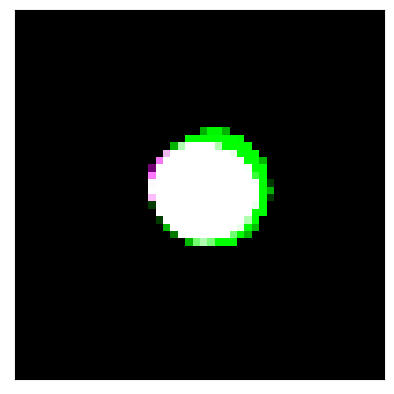

In [40]:
plot_image_1(voxel_image_droplet=voxel_image_cond_bl_1,voxel_image_surface=voxel_image_surf_cond_bl_1,image_sel=[9],image_t_sel=9,save_image=False,save_folder="/home/aaron/phd/files_effective_droplet_1/figures_surface/images_slices/",name="450_with_surf_")

/tmp/ipykernel_238/1723877385.py:20: RuntimeWarning: invalid value encountered in divide
  im_surf_tr_e1=im_surf_tr_e1/np.max(im_surf_tr_e1) *255
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


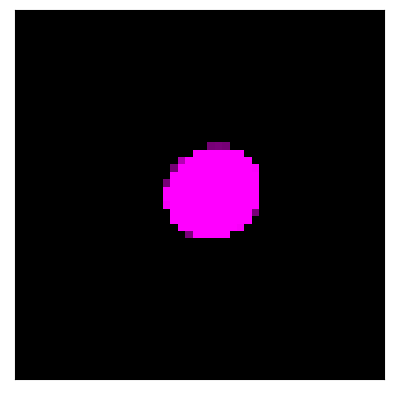

In [41]:
plot_image_1(voxel_image_droplet=voxel_image_cond_bl_2,voxel_image_surface=np.zeros_like(voxel_image_cond_bl_2),image_sel=[9],image_t_sel=9,save_image=False,save_folder="/home/aaron/phd/files_effective_droplet_1/figures_surface/images_slices/",name="450_no_surf_")

In [42]:
%%time
#With surface

mean_background_cond_1=[]
mean_foreground_cond_1=[]
overall_mean_e_cond_1=[]

mean_background_cond_bl_1=[]
mean_foreground_cond_bl_1=[]
overall_mean_e_cond_bl_1=[]



for i in range(len(voxel_image_cond_1)):
    mean_background_e,mean_foreground_e,overall_mean_e=image_thresholding_parallel(voxel_images=voxel_image_cond_1[i])
   
    mean_background_cond_1.append(mean_background_e)
    mean_foreground_cond_1.append(mean_foreground_e)
    overall_mean_e_cond_1.append(overall_mean_e)
    
    mean_background_bl_e,mean_foreground_bl_e,overall_mean_bl_e=image_thresholding_parallel(voxel_images=voxel_image_cond_bl_1[i])
   
    mean_background_cond_bl_1.append(mean_background_bl_e)
    mean_foreground_cond_bl_1.append(mean_foreground_bl_e)
    overall_mean_e_cond_bl_1.append(overall_mean_bl_e)

    
mean_background_cond_1=np.array(mean_background_cond_1)
mean_foreground_cond_1=np.array(mean_foreground_cond_1)
overall_mean_e_cond_1=np.array(overall_mean_e_cond_1)



mean_background_cond_bl_1=np.array(mean_background_cond_bl_1)
mean_foreground_cond_bl_1=np.array(mean_foreground_cond_bl_1)
overall_mean_e_cond_bl_1=np.array(overall_mean_e_cond_bl_1)
############################
############################

mean_dense_voxel_cond_1=np.mean(mean_foreground_cond_1,axis=1)
std_e_dense_voxel_cond_1=sem(mean_foreground_cond_1,axis=1)

mean_dilute_voxel_cond_1=np.mean(mean_background_cond_1,axis=1)
std_e_dilute_voxel_cond_1=sem(mean_background_cond_1,axis=1)

mean_all_voxel_cond_1=np.mean(overall_mean_e_cond_1,axis=1)
std_e_all_voxel_cond_1=sem(overall_mean_e_cond_1,axis=1)

###############################
#############################
mean_dense_voxel_cond_bl_1=np.mean(mean_foreground_cond_bl_1,axis=1)
std_e_dense_voxel_cond_bl_1=sem(mean_foreground_cond_bl_1,axis=1)

mean_dilute_voxel_cond_bl_1=np.mean(mean_background_cond_bl_1,axis=1)
std_e_dilute_voxel_cond_bl_1=sem(mean_background_cond_bl_1,axis=1)

mean_all_voxel_cond_bl_1=np.mean(overall_mean_e_cond_bl_1,axis=1)
std_e_all_voxel_cond_bl_1=sem(overall_mean_e_cond_bl_1,axis=1)


CPU times: user 287 ms, sys: 2.35 s, total: 2.63 s
Wall time: 3.87 s


In [43]:
%%time
#Without surface

mean_background_cond_2=[]
mean_foreground_cond_2=[]
overall_mean_e_cond_2=[]

mean_background_cond_bl_2=[]
mean_foreground_cond_bl_2=[]
overall_mean_e_cond_bl_2=[]



for i in range(len(voxel_image_cond_2)):
    mean_background_e,mean_foreground_e,overall_mean_e=image_thresholding_parallel(voxel_images=voxel_image_cond_2[i])
   
    mean_background_cond_2.append(mean_background_e)
    mean_foreground_cond_2.append(mean_foreground_e)
    overall_mean_e_cond_2.append(overall_mean_e)
    
    mean_background_bl_e,mean_foreground_bl_e,overall_mean_bl_e=image_thresholding_parallel(voxel_images=voxel_image_cond_bl_2[i])
   
    mean_background_cond_bl_2.append(mean_background_bl_e)
    mean_foreground_cond_bl_2.append(mean_foreground_bl_e)
    overall_mean_e_cond_bl_2.append(overall_mean_bl_e)

    
mean_background_cond_2=np.array(mean_background_cond_2)
mean_foreground_cond_2=np.array(mean_foreground_cond_2)
overall_mean_e_cond_2=np.array(overall_mean_e_cond_2)



mean_background_cond_bl_2=np.array(mean_background_cond_bl_2)
mean_foreground_cond_bl_2=np.array(mean_foreground_cond_bl_2)
overall_mean_e_cond_bl_2=np.array(overall_mean_e_cond_bl_2)
############################
############################

mean_dense_voxel_cond_2=np.mean(mean_foreground_cond_2,axis=1)
std_e_dense_voxel_cond_2=sem(mean_foreground_cond_2,axis=1)

mean_dilute_voxel_cond_2=np.mean(mean_background_cond_2,axis=1)
std_e_dilute_voxel_cond_2=sem(mean_background_cond_2,axis=1)

mean_all_voxel_cond_2=np.mean(overall_mean_e_cond_2,axis=1)
std_e_all_voxel_cond_2=sem(overall_mean_e_cond_2,axis=1)

###############################
#############################
mean_dense_voxel_cond_bl_2=np.mean(mean_foreground_cond_bl_2,axis=1)
std_e_dense_voxel_cond_bl_2=sem(mean_foreground_cond_bl_2,axis=1)

mean_dilute_voxel_cond_bl_2=np.mean(mean_background_cond_bl_2,axis=1)
std_e_dilute_voxel_cond_bl_2=sem(mean_background_cond_bl_2,axis=1)

mean_all_voxel_cond_bl_2=np.mean(overall_mean_e_cond_bl_2,axis=1)
std_e_all_voxel_cond_bl_2=sem(overall_mean_e_cond_bl_2,axis=1)


CPU times: user 296 ms, sys: 2.3 s, total: 2.59 s
Wall time: 3.81 s


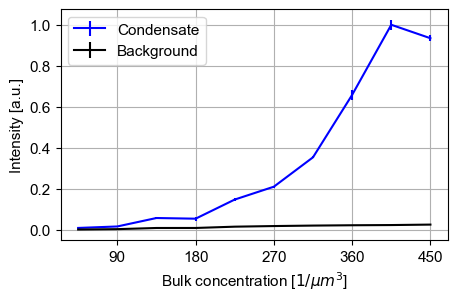

In [353]:
plt.figure(figsize=(5,3))
#plt.title("With surface, with blurring")

c_bulk=np.array(np.array(num_y_motifs)/V_box) 

norm=np.max(mean_dense_voxel_cond_bl_1)
plt.errorbar(c_bulk*10**9,mean_dense_voxel_cond_bl_1/norm,std_e_dense_voxel_cond_bl_1/norm,label="Condensate",color="blue")
plt.errorbar(c_bulk*10**9,mean_dilute_voxel_cond_bl_1/norm,std_e_dilute_voxel_cond_bl_1/norm,label="Background",color="black")
#plt.errorbar(c_bulk*10**9,mean_all_voxel_cond_bl_1,std_e_all_voxel_cond_bl_1,label="All")


#plt.yscale("log")

plt.legend(prop={'family': 'Arial','size': font_size})
plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)
plt.ylabel("Intensity [a.u.]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.grid()
#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/image_based_concentration_phases_surf_2.pdf",bbox_inches="tight",format="pdf")


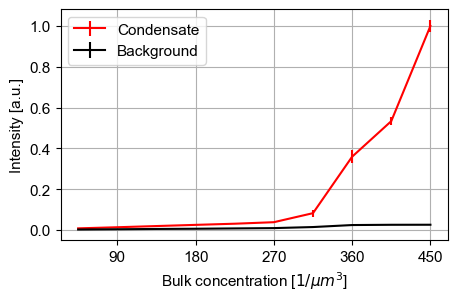

In [44]:
plt.figure(figsize=(5,3))
#plt.title("Without surface, with blurring")

c_bulk=np.array(np.array(num_y_motifs)/V_box) 

norm=np.max(mean_dense_voxel_cond_bl_2)
plt.errorbar(c_bulk*10**9,mean_dense_voxel_cond_bl_2/norm,std_e_dense_voxel_cond_bl_2/norm,label="Condensate",color="red")
plt.errorbar(c_bulk*10**9,mean_dilute_voxel_cond_bl_2/norm,std_e_dilute_voxel_cond_bl_2/norm,label="Background",color="black")
#plt.errorbar(c_bulk*10**9,mean_all_voxel_cond_bl_2,std_e_all_voxel_cond_bl_2,label="All")


#plt.yscale("log")

plt.legend(prop={'family': 'Arial','size': font_size})
plt.xticks(conc_bulk_label_x,conc_bulk_label_x,fontname = "Arial",fontsize=font_size)
plt.yticks(fontname = "Arial",fontsize=font_size)
plt.ylabel("Intensity [a.u.]",fontname = "Arial",fontsize=font_size)
plt.xlabel(r"Bulk concentration [$1/\mu m^3$]",fontname = "Arial",fontsize=font_size)
plt.grid()


#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/image_based_concentration_phases_no_surf_2.pdf",bbox_inches="tight",format="pdf")


# Influence of surface on amphiphile 

Data for amphiphile titration without surface was part of the following publication: https://pubs.acs.org/doi/10.1021/acs.nanolett.3c01301

In [45]:
#Generate coordinate list of conditions and repeats
#Amphiphile, no surface

add_num_am_1=[25000,24000,23000,22000,21000,20000,210000,29000,28000,27000,26000]
rep_num_am_1=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]
folder_am_1="/home/aaron/phd/files_effective_droplet_1/runs_depth_1/"  #simulation runs are shorter 
name_am_1="effective_droplet_1"

coords_cond_am_1=get_array_of_coords(folder=folder_am_1,name=name_am_1,add_num=add_num_am_1,rep_num=rep_num_am_1, name_particle="core",t_eval=-1)

/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125000.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125001.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125002.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125003.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125004.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125005.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125006.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125007.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125008.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125009.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125010.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_125011.h5
/hom

/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120000.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120001.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120002.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120003.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120004.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120005.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120006.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120007.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120008.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120009.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120010.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_120011.h5
/hom

/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_127019.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126000.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126001.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126002.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126003.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126004.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126005.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126006.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126007.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126008.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126009.h5
/home/aaron/phd/files_effective_droplet_1/runs_depth_1/effective_droplet_126010.h5
/hom

In [48]:
%%time
#apply DBSCAN in parallel to repeats of each condition

all_part_in_drop_am_1=[]
all_part_in_drop_std_e_am_1=[]
drop_num_am_1=[]
drop_num_std_e_am_1=[]
part_in_drop_am_1=[]
part_in_drop_std_e_am_1=[]
conc_in_drop_am_1=[]
conc_in_drop_std_e_am_1=[]

for i in range(len(coords_cond_am_1)):

    all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=coords_cond_am_1[i], eps=40, min_samples=10)
    
    all_part_in_drop_am_1.append(all_part_in_drop_x)
    all_part_in_drop_std_e_am_1.append(all_part_in_drop_std_e_x)
    drop_num_am_1.append(drop_num_x)
    drop_num_std_e_am_1.append(drop_num_std_e_x)
    part_in_drop_am_1.append(part_in_drop_x)
    part_in_drop_std_e_am_1.append(part_in_drop_std_e_x)
    conc_in_drop_am_1.append(conc_in_drop_x)
    conc_in_drop_std_e_am_1.append(conc_in_drop_std_e_x)

CPU times: user 128 ms, sys: 48.1 ms, total: 176 ms
Wall time: 3.35 s


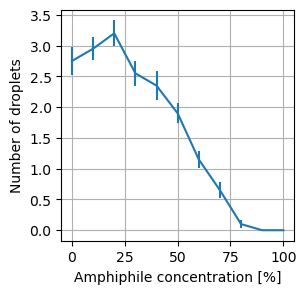

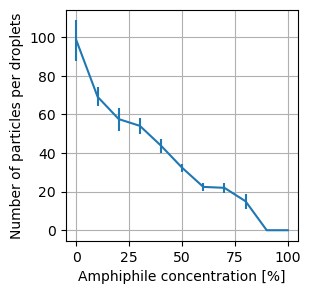

In [49]:
plt.figure(figsize=(3,3))

ax1= plt.subplot()

cases_c1=[0,10,20,30,40,50,60,70,80,90,100]


ax1.errorbar(cases_c1,drop_num_am_1,yerr=drop_num_std_e_am_1)
plt.ylabel("Number of droplets")
plt.xlabel("Amphiphile concentration [%]")
plt.grid()
plt.show()


plt.figure(figsize=(3,3))

ax1= plt.subplot()
ax1.errorbar(cases_c1,np.nan_to_num(part_in_drop_am_1,0),yerr=np.nan_to_num(part_in_drop_std_e_am_1,0))
plt.ylabel("Number of particles per droplets")
plt.xlabel("Amphiphile concentration [%]")
plt.grid()
plt.show()

In [50]:
#Generate coordinate list of conditions and repeats
#Amphiphile, with surface

add_num_am_2=[0,450,900,1350,1800,2250,2700,3150,3600,4050,4500]
rep_num_am_2=[0,1,2,3,4,5,6,7,8,9]
folder_am_2="/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/"
name_am_2="effective_droplet_"


coords_cond_am_2=get_array_of_coords(folder=folder_am_2,name=name_am_2,add_num=add_num_am_2,rep_num=rep_num_am_2, name_particle="core",t_eval=667)

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_0.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_1.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_2.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_3.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_4.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_5.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_6.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_7.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_8.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_9.h5
/home/aaron/phd/files_effective_droplet_1/test_run

/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_3605.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_3606.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_3607.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_3608.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_3609.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_4050.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_4051.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_4052.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_4053.h5
/home/aaron/phd/files_effective_droplet_1/test_runs_1/surface_amph_test/effective_droplet_4054.h5
/home/aaron/phd/file

In [51]:
%%time
#apply DBSCAN in parallel to repeats of each condition

all_part_in_drop_am_2=[]
all_part_in_drop_std_e_am_2=[]
drop_num_am_2=[]
drop_num_std_e_am_2=[]
part_in_drop_am_2=[]
part_in_drop_std_e_am_2=[]
conc_in_drop_am_2=[]
conc_in_drop_std_e_am_2=[]

for i in range(len(coords_cond_am_2)):

    all_part_in_drop_x,all_part_in_drop_std_e_x,drop_num_x,drop_num_std_e_x,part_in_drop_x,part_in_drop_std_e_x,conc_in_drop_x,conc_in_drop_std_e_x=calculate_statistics(arrays=coords_cond_am_2[i], eps=40, min_samples=10)
    
    all_part_in_drop_am_2.append(all_part_in_drop_x)
    all_part_in_drop_std_e_am_2.append(all_part_in_drop_std_e_x)
    drop_num_am_2.append(drop_num_x)
    drop_num_std_e_am_2.append(drop_num_std_e_x)
    part_in_drop_am_2.append(part_in_drop_x)
    part_in_drop_std_e_am_2.append(part_in_drop_std_e_x)
    conc_in_drop_am_2.append(conc_in_drop_x)
    conc_in_drop_std_e_am_2.append(conc_in_drop_std_e_x)

CPU times: user 83.6 ms, sys: 1.01 ms, total: 84.6 ms
Wall time: 3.55 s


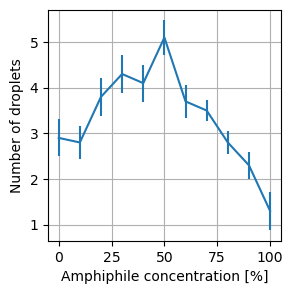

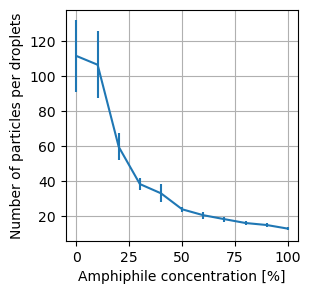

In [52]:
plt.figure(figsize=(3,3))

ax1= plt.subplot()

cases_c1=[0,10,20,30,40,50,60,70,80,90,100]


ax1.errorbar(cases_c1,drop_num_am_2,yerr=drop_num_std_e_am_2)
plt.ylabel("Number of droplets")
plt.xlabel("Amphiphile concentration [%]")
plt.grid()
plt.show()


plt.figure(figsize=(3,3))

ax1= plt.subplot()
ax1.errorbar(cases_c1,part_in_drop_am_2,yerr=part_in_drop_std_e_am_2)
plt.ylabel("Number of particles per droplets")
plt.xlabel("Amphiphile concentration [%]")
plt.grid()
plt.show()

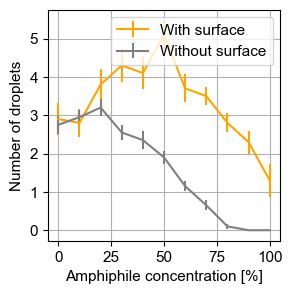

In [53]:
plt.figure(figsize=(3,3))

ax1= plt.subplot()

cases_c1=[0,10,20,30,40,50,60,70,80,90,100]

ax1.errorbar(cases_c1,drop_num_am_2,yerr=drop_num_std_e_am_2,label="With surface",color="orange")
ax1.errorbar(cases_c1,drop_num_am_1,yerr=drop_num_std_e_am_1,label="Without surface",color="grey")

plt.legend(prop={'family': 'Arial','size': 11})
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel("Number of droplets",fontname = "Arial",fontsize=11)
plt.xlabel("Amphiphile concentration [%]",fontname = "Arial",fontsize=11)
plt.grid()
#plt.show()
#plt.savefig("/home/aaron/phd/files_effective_droplet_1/figures_surface/titration_amph_surf_1.pdf",bbox_inches="tight",format="pdf")